<a href="https://colab.research.google.com/github/Sarthaak-19/IncodeVision-ML-Internship/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset
url = "https://raw.githubusercontent.com/KunjMaheshwari/Email-Spam-Detector/master/spam.csv"

df = pd.read_csv(url, encoding='latin-1')

print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [ ]:
# EDA
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [ ]:
# data cleaning
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5169, 2)

In [ ]:
# column rename
df.rename(columns={'v1':'label','v2':'text'},inplace=True)

In [ ]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [ ]:
df['text'].unique()

array(['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
       'Ok lar... Joking wif u oni...',
       "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
       ..., 'Pity, * was in mood for that. So...any other suggestions?',
       "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free",
       'Rofl. Its true to its name'], dtype=object)

In [ ]:
# data preprocessing
df['label']=df['label'].map({'ham':0,'spam':1})

In [ ]:
# text--->numbers
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(ngram_range=(1,2),stop_words='english')

In [ ]:
# features
x=vectorizer.fit_transform(df['text'])
y=df['label']

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# model selection naive bayes
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB(alpha=0.1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression(max_iter=1000)
model_lr.fit(x_train,y_train)
y_pred_lr=model_lr.predict(x_test)

In [ ]:
# svm
from sklearn.svm import SVC
svm=SVC(random_state=42)
svm.fit(x_train,y_train)
y_pred_svm=svm.predict(x_test)

In [ ]:
#  model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print("Naive Bayes")
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

print('\n')
print("Logistic Regression")
print(accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

print('\n')
print("SVM")
print(accuracy_score(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))

Naive Bayes
0.9787234042553191
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       889
           1       0.89      0.97      0.93       145

    accuracy                           0.98      1034
   macro avg       0.94      0.97      0.96      1034
weighted avg       0.98      0.98      0.98      1034



Logistic Regression
0.9148936170212766
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       889
           1       0.98      0.40      0.57       145

    accuracy                           0.91      1034
   macro avg       0.95      0.70      0.76      1034
weighted avg       0.92      0.91      0.90      1034



SVM
0.9468085106382979
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       889
           1       1.00      0.62      0.77       145

    accuracy                           0.95      1034
   macro avg       0.97      0.

In [ ]:
cm_nv=confusion_matrix(y_test,y_pred)
cm_lr=confusion_matrix(y_test,y_pred_lr)
cm_svm=confusion_matrix(y_test,y_pred_svm)

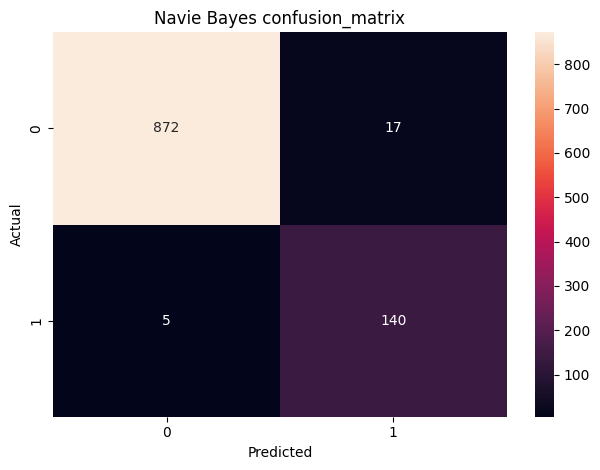

In [ ]:
sns.heatmap(cm_nv,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Navie Bayes confusion_matrix')
plt.tight_layout()

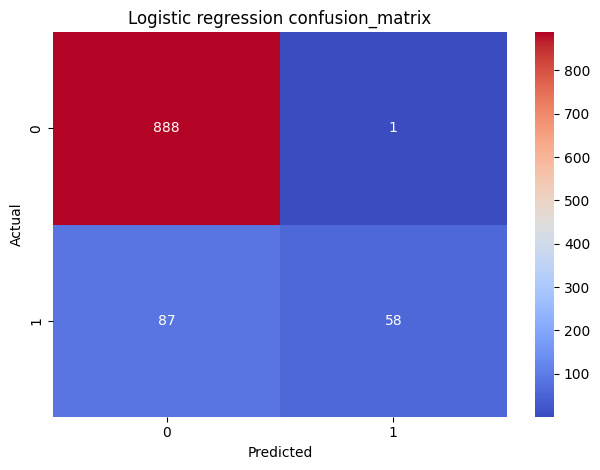

In [47]:
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic regression confusion_matrix')
plt.tight_layout()

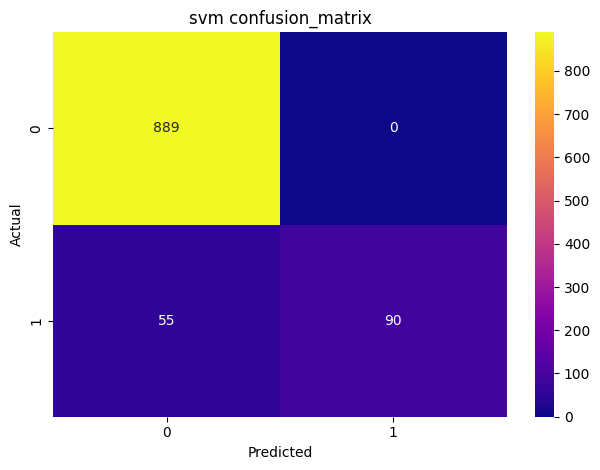

In [48]:
sns.heatmap(cm_svm,annot=True,fmt='d',cmap='plasma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('svm confusion_matrix')
plt.tight_layout()

In [51]:
# user input
print('navies-bayes')
msg=input('Enter your msg:-')
vec=vectorizer.transform([msg])

predictions=model.predict(vec)
result='spam' if predictions[0]==1 else 'not-spam'
print(f"your msg are {result}")

navies-bayes
Enter your msg:-hey i love linux
your msg are not-spam


In [57]:
# user input
print('svm')
msg=input('Enter your msg:-')
vec=vectorizer.transform([msg])

predictions=svm.predict(vec)
result='spam' if predictions[0]==1 else 'not-spam'
print(f"your msg are {result}")

svm
Enter your msg:-free entry 
your msg are spam


In [58]:
# user input
print('Logistic regression ')
msg=input('Enter your msg:-')
vec=vectorizer.transform([msg])

predictions=model_lr.predict(vec)
result='spam' if predictions[0]==1 else 'not-spam'
print(f"your msg are {result}")

Logistic regression 
Enter your msg:-hey iam python developer
your msg are not-spam
